# Stage 6 - Advise management

**Input:** the final cost per strategy (`data/final_costs.csv`, Stage 5), the Day-Ahead residual
per strategy (`data/residual_da.csv`, Stage 4), the imbalance result (`data/imbalance.csv`, Stage
5), and the futures positions and prices (`data/hedge_positions.csv`, `data/selected_products.csv`,
`data/hpfc.csv`) needed to reconstruct a monthly procurement price

**Output:** a final cost-and-risk comparison table across `UNHEDGED`, `COARSE_CAL`, and `GRANULAR`
(`data/strategy_comparison.csv`) and a management recommendation


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

DATA = "../data"
DT = 0.25   # quarter-hour, in hours
C_CAL, C_GRAN, C_UNHEDGED = "#DD8452", "#4C72B0", "#8172B3"   # COARSE_CAL, GRANULAR, UNHEDGED
STRATEGIES = ["UNHEDGED", "COARSE_CAL", "GRANULAR"]
COLORS = {"UNHEDGED": C_UNHEDGED, "COARSE_CAL": C_CAL, "GRANULAR": C_GRAN}

final_costs = pd.read_csv(f"{DATA}/final_costs.csv").set_index("strategy").reindex(STRATEGIES)
residual    = pd.read_csv(f"{DATA}/residual_da.csv")
imbalance   = pd.read_csv(f"{DATA}/imbalance.csv")
positions   = pd.read_csv(f"{DATA}/hedge_positions.csv")
selected    = pd.read_csv(f"{DATA}/selected_products.csv")
hpfc        = pd.read_csv(f"{DATA}/hpfc.csv")[["timestamp_utc", "period", "is_peak"]]

df = residual.merge(hpfc, on="timestamp_utc", validate="one_to_one")
df = df.merge(imbalance[["timestamp_utc", "total_actual_mwh", "imbalance_volume_mwh", "imbalance_price_eur_mwh"]],
              on="timestamp_utc", validate="one_to_one")
df["t_local"] = pd.to_datetime(df["timestamp_utc"], utc=True).dt.tz_convert("Europe/Berlin")
assert df.isna().sum().sum() == 0

print("merged grid:", df.shape, "-> Stage 4 residual x HPFC block/Peak grid x Stage 5 imbalance")
print("Stage 5 final cost per strategy:")
final_costs

merged grid: (35136, 15) -> Stage 4 residual x HPFC block/Peak grid x Stage 5 imbalance
Stage 5 final cost per strategy:


,C_futures_EUR,C_residual_DA_EUR,C_forecast_EUR,C_imb_EUR,Premium_imb_EUR,C_final_EUR,saving_vs_UNHEDGED_EUR
strategy,,,,,,,
UNHEDGED,0.00,"3,506,703.99","3,506,703.99","30,503.84","13,589.24","3,537,207.83",0.00
COARSE_CAL,"3,493,701.73","-42,735.09","3,450,966.64","30,503.84","13,589.24","3,481,470.48","55,737.35"
GRANULAR,"3,493,705.92","-42,198.57","3,451,507.34","30,503.84","13,589.24","3,482,011.18","55,196.65"


## 1. Reconstruct a per-quarter-hour procurement cost

Stages 4-5 only saved the *annual* `C_futures`. A monthly comparison needs a cost *time series*, so
$C_{futures}$ is broken back down to the quarter-hour it accrues in, exactly as it was built up in
Stage 4: a Base position pays $P_{base,b}$ on every interval of its block, a Peak position pays
$P_{peak,b}$ only on that block's Peak intervals.

$$cost_t(strategy) = \underbrace{\Delta t \big(x_{base,b(t)} P_{base,b(t)} + x_{peak,b(t)} P_{peak,b(t)} \mathbb{1}[\text{is\_peak}_t]\big)}_{\text{futures, fixed}} + \underbrace{R_t^{DA} \cdot P_t^{DA}}_{\text{Stage 4}} + \underbrace{I_t \cdot P_t^{imb}}_{\text{Stage 5}}$$

Summed over the full year this must reproduce Stage 5's $C_{final}$ exactly - a second,
independent check (beyond Stage 4's own reconciliation) that the two notebooks agree.

In [2]:
price_base = selected[selected["load_type"] == "BASE"].set_index("delivery_period")["price_eur_mwh"]
price_peak = selected[selected["load_type"] == "PEAK"].set_index("delivery_period")["price_eur_mwh"]

cal_pos  = positions[(positions["strategy"] == "COARSE_CAL")].iloc[0]
df["futures_cost_COARSE_CAL"] = DT * (cal_pos["x_base_MW"] * price_base["CAL"]
                                       + cal_pos["x_peak_MW"] * price_peak["CAL"] * df["is_peak"])

gran_pos = positions[positions["strategy"] == "GRANULAR"].set_index("block")
df["x_base_g"] = df["period"].map(gran_pos["x_base_MW"])
df["x_peak_g"] = df["period"].map(gran_pos["x_peak_MW"])
df["futures_cost_GRANULAR"] = DT * (df["x_base_g"] * df["period"].map(price_base)
                                     + df["x_peak_g"] * df["period"].map(price_peak) * df["is_peak"])
df["futures_cost_UNHEDGED"] = 0.0

for s in STRATEGIES:
    df[f"total_cost_{s}"] = (df[f"futures_cost_{s}"] + df[f"R_DA_{s}"] * df["day_ahead_price_eur_mwh"]
                              + df["imbalance_volume_mwh"] * df["imbalance_price_eur_mwh"])

check = pd.DataFrame({
    "C_futures (reconstructed)": {s: df[f"futures_cost_{s}"].sum() for s in STRATEGIES},
    "C_futures (Stage 4)":       final_costs["C_futures_EUR"],
    "C_final (reconstructed)":   {s: df[f"total_cost_{s}"].sum() for s in STRATEGIES},
    "C_final (Stage 5)":         final_costs["C_final_EUR"],
})
assert np.allclose(check["C_futures (reconstructed)"], check["C_futures (Stage 4)"], atol=1e-6)
assert np.allclose(check["C_final (reconstructed)"], check["C_final (Stage 5)"], atol=1e-6)
print("Reconciled: the quarter-hourly cost series sums to Stage 5's C_futures and C_final for every strategy.")
check

Reconciled: the quarter-hourly cost series sums to Stage 5's C_futures and C_final for every strategy.


,C_futures (reconstructed),C_futures (Stage 4),C_final (reconstructed),C_final (Stage 5)
UNHEDGED,0.00,0.00,"3,537,207.83","3,537,207.83"
COARSE_CAL,"3,493,701.73","3,493,701.73","3,481,470.48","3,481,470.48"
GRANULAR,"3,493,705.92","3,493,705.92","3,482,011.18","3,482,011.18"


## 2. The eight comparison measures

- **Final annual procurement cost** - $C_{final}$, Stage 5.
- **Final average price of actual load** - $C_{final} / \sum_t A_t$, in EUR/MWh; comparable across
  strategies because $A_t$ (realised consumption) does not depend on the hedge.
- **Saving vs. UNHEDGED** - $C_{final}^{UNHEDGED} - C_{final}^{strategy}$, Stage 5.
- **Monthly procurement-price standard deviation / range** - resample $cost_t/A_t$ to monthly EUR/MWh
  averages, then take the standard deviation and (max - min) across the 12 months: how much the
  realised unit price moves through the year.
- **Absolute residual Day-Ahead volume** - $\sum_t |R_t^{DA}|$, Stage 3/4: the physical spot exposure
  left after the futures hedge.
- **Residual-load RMSE** - $\sqrt{\text{mean}_t\, (R_t^{DA})^2}$, Stage 3: shape-fit quality of the
  hedge.
- **Imbalance settlement and premium** - $C_{imb}$, $Premium_{imb}$, Stage 5 - identical for every
  strategy (Stage 5, Section 1), since $I_t = A_t - L_t$ never involves the hedge.

In [3]:
monthly_cost = df.set_index("t_local")[[f"total_cost_{s}" for s in STRATEGIES]].resample("MS").sum()
monthly_load = df.set_index("t_local")["total_actual_mwh"].resample("MS").sum()
monthly_price = monthly_cost.div(monthly_load, axis=0)
monthly_price.columns = STRATEGIES

total_actual_mwh = df["total_actual_mwh"].sum()

comparison = pd.DataFrame({
    "final_cost_EUR":                 final_costs["C_final_EUR"],
    "final_avg_price_EUR_per_MWh":    final_costs["C_final_EUR"] / total_actual_mwh,
    "saving_vs_UNHEDGED_EUR":         final_costs["saving_vs_UNHEDGED_EUR"],
    "monthly_price_std_EUR_per_MWh":  monthly_price.std(),
    "monthly_price_range_EUR_per_MWh": monthly_price.max() - monthly_price.min(),
    "abs_residual_DA_MWh":            {s: df[f"R_DA_{s}"].abs().sum() for s in STRATEGIES},
    "residual_load_RMSE_MWh_per_qh":  {s: np.sqrt(np.mean(df[f"R_DA_{s}"] ** 2)) for s in STRATEGIES},
    "C_imb_EUR":                      final_costs["C_imb_EUR"],
    "Premium_imb_EUR":                final_costs["Premium_imb_EUR"],
}).reindex(STRATEGIES)

comparison.T

,UNHEDGED,COARSE_CAL,GRANULAR
final_cost_EUR,"3,537,207.83","3,481,470.48","3,482,011.18"
final_avg_price_EUR_per_MWh,82.00,80.71,80.72
saving_vs_UNHEDGED_EUR,0.00,"55,737.35","55,196.65"
monthly_price_std_EUR_per_MWh,20.15,2.43,18.56
monthly_price_range_EUR_per_MWh,58.43,9.08,47.08
abs_residual_DA_MWh,"43,000.00","12,760.13","11,985.15"
residual_load_RMSE_MWh_per_qh,1.32,0.44,0.42
C_imb_EUR,"30,503.84","30,503.84","30,503.84"
Premium_imb_EUR,"13,589.24","13,589.24","13,589.24"


**Reading the table.** `UNHEDGED` is dominated on every single measure - highest cost, highest
average price, most volatile month to month, full physical exposure. Between the two hedged
strategies the picture splits:

- **Cost is a near-tie.** `COARSE_CAL` is only 541 EUR/year cheaper than `GRANULAR` (55,737 vs.
  55,196 EUR saved) - about 0.02% of the ~3.48m EUR annual bill, well inside what one realised price
  path can flip either way.
- **Shape/volume risk marginally favours `GRANULAR`.** Lower residual RMSE (0.42 vs. 0.44
  MWh/quarter-hour) and lower absolute residual volume (11,985 vs. 12,760 MWh) - it tracks the load
  shape a bit more closely, as already found in Stage 3.
- **Monthly price stability strongly favours `COARSE_CAL`.** Its monthly-price standard deviation is
  about **8x smaller** than `GRANULAR`'s (2.4 vs. 18.6 EUR/MWh) and its monthly range roughly **5x
  smaller** (9.1 vs. 47.1 EUR/MWh). A single flat annual position produces a nearly constant monthly
  unit cost, while `GRANULAR`'s six blocks are priced at their own quarter/month's futures level -
  which faithfully passes the *market's* seasonal price shape (cheap summer, expensive Q4) straight
  into the realised monthly bill.
- **Imbalance is identical for both** (30,504 EUR settlement, 13,589 EUR premium) - confirming Stage
  5's result that no futures hedge touches this line.

## 3. Visualize cost, stability, and shape risk

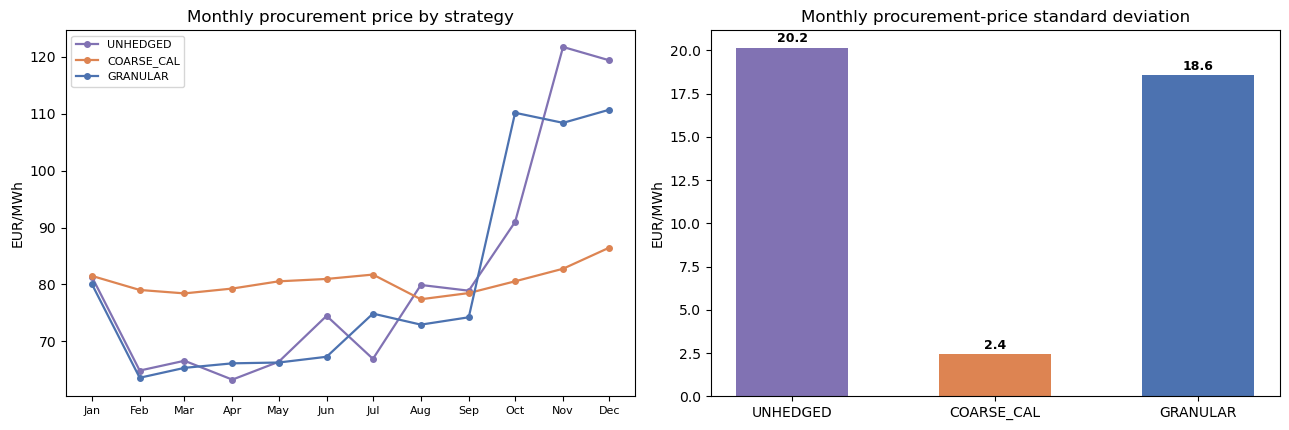

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

for strategy in STRATEGIES:
    axes[0].plot(monthly_price.index, monthly_price[strategy], marker="o", ms=4, lw=1.6,
                 color=COLORS[strategy], label=strategy)
axes[0].set_xticks(monthly_price.index); axes[0].set_xticklabels([d.strftime("%b") for d in monthly_price.index], fontsize=8)
axes[0].set_ylabel("EUR/MWh"); axes[0].set_title("Monthly procurement price by strategy")
axes[0].legend(fontsize=8)

xs = np.arange(3)
axes[1].bar(xs, comparison.loc[STRATEGIES, "monthly_price_std_EUR_per_MWh"], color=[COLORS[s] for s in STRATEGIES], width=0.55)
axes[1].set_xticks(xs); axes[1].set_xticklabels(STRATEGIES)
axes[1].set_ylabel("EUR/MWh"); axes[1].set_title("Monthly procurement-price standard deviation")
for xi, s in zip(xs, STRATEGIES):
    v = comparison.loc[s, "monthly_price_std_EUR_per_MWh"]
    axes[1].annotate(f"{v:,.1f}", (xi, v), xytext=(0, 4), textcoords="offset points", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout(); plt.show()

**Comment.** The left panel makes the trade-off visible directly: `COARSE_CAL`'s line
(orange) is nearly flat around 78-87 EUR/MWh all year, while `GRANULAR` (blue) tracks much closer to
`UNHEDGED` (purple) in shape - cheap in the shoulder months, then rising sharply with `UNHEDGED` into
Oct-Dec (its Q4 block was priced at 101-134 EUR/MWh, the winter futures premium already seen in Stage
2). `GRANULAR` still ends the year *below* `UNHEDGED` throughout, but it does not insulate the
monthly bill from the market's own seasonal curve the way `COARSE_CAL`'s single annual price does.
The right panel quantifies exactly how much: `COARSE_CAL`'s monthly-price volatility is a small
fraction of `GRANULAR`'s or `UNHEDGED`'s.

## 4. Recommendation

**Recommend `COARSE_CAL`.**

This is not "the cheapest strategy wins" - on realised annual cost `COARSE_CAL` and `GRANULAR` are
statistically indistinguishable (541 EUR apart on a 3.48m EUR bill), and `GRANULAR` is in fact the
*more* shape-accurate hedge (lower RMSE, lower residual volume), exactly what the brief's warning
about picking on cost alone is there to guard against. The reason to prefer `COARSE_CAL` here is
risk, not cost: it delivers essentially the same annual saving with dramatically less month-to-month
procurement-price volatility (Section 2-3). For a retailer's risk-management objective - protecting
the company against adverse wholesale-price movements while pricing and budgeting a customer
portfolio through the year - a stable, predictable monthly cost is itself a form of risk reduction,
independent of the annual total. `GRANULAR`'s marginally better shape fit does not translate into a
materially lower realised cost or a materially smaller *annual* residual exposure (both differences
are in the single digits of percent), so it does not offset the large increase in cost volatility it
brings.

**What this recommendation does not claim.**

- It is a backtest on one realised 2024 price path, not evidence that either hedge was designed as
  (or performed as) a speculative profit strategy - both were sized purely for value neutrality and
  shape fit in Stage 3, before any 2024 price was known.
- `GRANULAR` remains the theoretically better hedge for pure physical/shape risk, and would be the
  better choice if the mandate weighted shape/volume precision above budget predictability (e.g. a
  desk primarily worried about physical balancing exposure rather than headline pricing).
- Neither hedge removes the volume/forecast risk quantified by `C_imb` and `Premium_imb` (Stage 5) -
  that risk is identical under all three strategies and would need better forecasting, not a
  different futures mix, to shrink.

**Residual risks with `COARSE_CAL`.** A single annual block cannot adapt if the *relative* shape of
Peak vs. Off-Peak or the seasonal pattern shifts away from the 2019-2022 history used to build the
HPFC (Stage 2's basis risk); it also still leaves ~12,760 MWh/year (about 30% of load) to Day-Ahead
shaping and the full, hedge-independent imbalance exposure quantified above.

## 5. Save the comparison

In [5]:
comparison_out = comparison.rename_axis("strategy").reset_index()
comparison_out.to_csv(f"{DATA}/strategy_comparison.csv", index=False)

monthly_price_out = monthly_price.rename_axis("month").reset_index()
monthly_price_out.to_csv(f"{DATA}/monthly_price_by_strategy.csv", index=False)

print("saved:", f"{DATA}/strategy_comparison.csv", comparison_out.shape)
print("saved:", f"{DATA}/monthly_price_by_strategy.csv", monthly_price_out.shape)
comparison_out

saved: ../data/strategy_comparison.csv (3, 10)
saved: ../data/monthly_price_by_strategy.csv (12, 4)


,strategy,final_cost_EUR,final_avg_price_EUR_per_MWh,saving_vs_UNHEDGED_EUR,monthly_price_std_EUR_per_MWh,monthly_price_range_EUR_per_MWh,abs_residual_DA_MWh,residual_load_RMSE_MWh_per_qh,C_imb_EUR,Premium_imb_EUR
0,UNHEDGED,"3,537,207.83",82.00,0.00,20.15,58.43,"43,000.00",1.32,"30,503.84","13,589.24"
1,COARSE_CAL,"3,481,470.48",80.71,"55,737.35",2.43,9.08,"12,760.13",0.44,"30,503.84","13,589.24"
2,GRANULAR,"3,482,011.18",80.72,"55,196.65",18.56,47.08,"11,985.15",0.42,"30,503.84","13,589.24"
